In [1]:
!pip install langchain langchain-community sentence-transformers faiss-cpu pypdf
print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.0/346.0 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
Done!


In [1]:
!pip install langchain langchain-community sentence-transformers faiss-cpu pypdf
print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.0/346.0 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
Done!


In [2]:
import urllib.request

# Download a medical PDF about pneumonia (NIH/public domain)
url = "https://www.nhlbi.nih.gov/files/docs/public/lung/pneumonia-plain-language.pdf"

try:
    urllib.request.urlretrieve(url, "pneumonia_guide.pdf")
    print("Downloaded!")
except:
    print("Download failed — using manual text instead")

Download failed — using manual text instead


In [3]:
import urllib.request

# Download a medical PDF about pneumonia (NIH/public domain)
url = "https://www.nhlbi.nih.gov/files/docs/public/lung/pneumonia-plain-language.pdf"

try:
    urllib.request.urlretrieve(url, "pneumonia_guide.pdf")
    print("Downloaded!")
except:
    print("Download failed — using manual text instead")

Download failed — using manual text instead


In [4]:
# Medical knowledge base — curated text about chest X-ray findings
medical_texts = [
    """Pneumonia is an infection that inflames the air sacs in one or both lungs.
    The air sacs may fill with fluid or pus, causing cough with phlegm or pus,
    fever, chills, and difficulty breathing. Bacteria, viruses, and fungi can cause pneumonia.
    Chest X-rays show pneumonia as white or grey cloudy patches in the lungs.""",

    """Normal chest X-ray findings include clear lung fields that appear dark on X-ray,
    visible lung markings throughout both lungs, a clear costophrenic angle,
    normal heart size (less than half the chest width), and a visible diaphragm.
    The trachea should be midline and the bones should appear intact.""",

    """Bacterial pneumonia on chest X-ray typically shows lobar or segmental consolidation,
    meaning an entire lobe appears white/opaque. Air bronchograms may be visible within
    the consolidation. Lower lobes are most commonly affected. The consolidation
    represents alveoli filled with inflammatory exudate instead of air.""",

    """Viral pneumonia on chest X-ray shows bilateral interstitial infiltrates,
    meaning both lungs show increased markings in a diffuse pattern.
    Unlike bacterial pneumonia, viral pneumonia rarely causes complete lobar consolidation.
    Ground glass opacity is a common finding in viral pneumonia including COVID-19.""",

    """Pleural effusion appears as a white opacity at the base of the lung on chest X-ray.
    It represents fluid accumulation in the pleural space between the lung and chest wall.
    Small effusions blunt the costophrenic angle. Large effusions can shift the mediastinum.
    Pleural effusion can be a complication of pneumonia.""",

    """Consolidation on chest X-ray means lung tissue has become solid instead of air-filled.
    It appears as a white or grey opacity replacing the normal dark lung tissue.
    Consolidation is caused by filling of alveoli with fluid, pus, blood, or cells.
    It is the hallmark radiographic finding of bacterial pneumonia.""",

    """Grad-CAM or Gradient-weighted Class Activation Mapping is an explainability technique
    for convolutional neural networks. It highlights regions of an input image that were
    most important for the model's prediction. In chest X-ray analysis, Grad-CAM helps
    radiologists verify that the AI model is focusing on clinically relevant lung regions.""",

    """ResNet50 is a deep convolutional neural network with 50 layers using residual connections.
    Residual connections allow gradients to flow directly through skip connections,
    solving the vanishing gradient problem in deep networks. ResNet50 pretrained on ImageNet
    can be fine-tuned for medical image classification with limited training data.""",

    """Transfer learning in medical imaging involves using neural networks pretrained on
    large natural image datasets like ImageNet and fine-tuning them on medical images.
    This approach works because early convolutional layers learn universal features
    like edges and textures that are useful across different image domains.""",

    """AUC-ROC (Area Under the Receiver Operating Characteristic Curve) measures a classifier's
    ability to distinguish between classes across all thresholds. A value of 0.5 means
    random guessing while 1.0 means perfect classification. In medical AI, AUC-ROC
    is preferred over accuracy because it handles class imbalance better.""",
]

print(f"Knowledge base: {len(medical_texts)} documents ready")

Knowledge base: 10 documents ready


In [5]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# Step 1 — Split text into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50
)

chunks = text_splitter.create_documents(medical_texts)
print(f"Total chunks: {len(chunks)}")
print(f"\nExample chunk:")
print(chunks[0].page_content)

ModuleNotFoundError: No module named 'langchain.text_splitter'

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# Step 1 — Split text into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50
)

chunks = text_splitter.create_documents(medical_texts)
print(f"Total chunks: {len(chunks)}")
print(f"\nExample chunk:")
print(chunks[0].page_content)

/tmp/ipykernel_2711/3509410374.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


Total chunks: 20

Example chunk:
Pneumonia is an infection that inflames the air sacs in one or both lungs. 
    The air sacs may fill with fluid or pus, causing cough with phlegm or pus,


In [7]:
# Step 2 — Load embedding model
print("Loading embedding model...")
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
print("Embedding model loaded!")

# Step 3 — Create FAISS vector store
print("Creating vector store...")
vectorstore = FAISS.from_documents(chunks, embeddings)
print(f"Vector store created!")

# Test search
query = "what does pneumonia look like on xray"
results = vectorstore.similarity_search(query, k=3)
print(f"\nQuery: '{query}'")
print(f"\nTop 3 results:")
for i, doc in enumerate(results):
    print(f"\n{i+1}. {doc.page_content[:150]}...")

Loading embedding model...


/tmp/ipykernel_2711/1059222044.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded!
Creating vector store...
Vector store created!

Query: 'what does pneumonia look like on xray'

Top 3 results:

1. Bacterial pneumonia on chest X-ray typically shows lobar or segmental consolidation,
    meaning an entire lobe appears white/opaque. Air bronchograms...

2. Viral pneumonia on chest X-ray shows bilateral interstitial infiltrates,
    meaning both lungs show increased markings in a diffuse pattern....

3. fever, chills, and difficulty breathing. Bacteria, viruses, and fungi can cause pneumonia.
    Chest X-rays show pneumonia as white or grey cloudy pat...


In [8]:
# Save vector store permanently
vectorstore.save_local('/content/drive/MyDrive/medical_vectorstore')
print("Vector store saved to Drive!")

# Test reload works
vectorstore_loaded = FAISS.load_local(
    '/content/drive/MyDrive/medical_vectorstore',
    embeddings,
    allow_dangerous_deserialization=True
)
test = vectorstore_loaded.similarity_search("normal xray findings", k=1)
print(f"Reload test: {test[0].page_content[:100]}...")
print("Vector store working!")

Vector store saved to Drive!
Reload test: Normal chest X-ray findings include clear lung fields that appear dark on X-ray,
    visible lung ma...
Vector store working!


In [9]:
!pip install -q langchain-huggingface
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.chains import RetrievalQA
from langchain_community.llms import HuggingFacePipeline
from transformers import pipeline
import torch

print("Loading LLM...")
# Load a small but capable LLM — runs on free Colab
pipe = pipeline(
    "text2text-generation",
    model="google/flan-t5-base",
    max_new_tokens=200,
    device=0 if torch.cuda.is_available() else -1
)
llm = HuggingFacePipeline(pipeline=pipe)
print("LLM loaded!")

ModuleNotFoundError: No module named 'langchain.chains'

In [10]:
!pip install -q langchain-huggingface transformers
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFacePipeline
from langchain.chains.retrieval_qa.base import RetrievalQA
from transformers import pipeline
import torch

print("Loading LLM...")
pipe = pipeline(
    "text2text-generation",
    model="google/flan-t5-base",
    max_new_tokens=200,
    device=0 if torch.cuda.is_available() else -1
)
llm = HuggingFacePipeline(pipeline=pipe)
print("LLM loaded!")

ModuleNotFoundError: No module named 'langchain.chains'

In [11]:
!pip install -q langchain-classic transformers langchain-huggingface

In [12]:
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFacePipeline
from langchain.chains import RetrievalQA
from transformers import pipeline
import torch

print("Loading LLM...")
pipe = pipeline(
    "text2text-generation",
    model="google/flan-t5-base",
    max_new_tokens=200,
    device=0 if torch.cuda.is_available() else -1
)
llm = HuggingFacePipeline(pipeline=pipe)
print("LLM loaded!")

ModuleNotFoundError: No module named 'langchain.chains'

In [13]:
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFacePipeline
from transformers import pipeline
import torch

print("Loading LLM...")
pipe = pipeline(
    "text2text-generation",
    model="google/flan-t5-base",
    max_new_tokens=200,
    device=0 if torch.cuda.is_available() else -1
)
llm = HuggingFacePipeline(pipeline=pipe)
print("LLM loaded!")

Loading LLM...


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

KeyError: "Unknown task text2text-generation, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

In [14]:
from langchain_huggingface import HuggingFacePipeline
from transformers import pipeline
import torch

print("Loading LLM...")
pipe = pipeline(
    "text-generation",
    model="facebook/opt-125m",
    max_new_tokens=200,
    device=0 if torch.cuda.is_available() else -1
)
llm = HuggingFacePipeline(pipeline=pipe)
print("LLM loaded!")

Loading LLM...


config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/251M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


LLM loaded!


In [15]:
def rag_answer(question, vectorstore, llm, k=3):
    # Step 1 — Retrieve relevant chunks
    docs = vectorstore.similarity_search(question, k=k)

    # Step 2 — Build context from retrieved chunks
    context = "\n\n".join([doc.page_content for doc in docs])

    # Step 3 — Build prompt
    prompt = f"""Based on the following medical information, answer the question.

Context:
{context}

Question: {question}

Answer:"""

    # Step 4 — Generate answer
    response = llm.invoke(prompt)

    return response, docs

# Test it
question = "What does pneumonia look like on a chest xray?"
answer, sources = rag_answer(question, vectorstore, llm)

print(f"Question: {question}")
print(f"\nAnswer: {answer}")
print(f"\nSources used: {len(sources)} chunks retrieved")

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=200) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Question: What does pneumonia look like on a chest xray?

Answer: Based on the following medical information, answer the question.

Context:
Bacterial pneumonia on chest X-ray typically shows lobar or segmental consolidation,
    meaning an entire lobe appears white/opaque. Air bronchograms may be visible within

Viral pneumonia on chest X-ray shows bilateral interstitial infiltrates,
    meaning both lungs show increased markings in a diffuse pattern.

Normal chest X-ray findings include clear lung fields that appear dark on X-ray,
    visible lung markings throughout both lungs, a clear costophrenic angle,

Question: What does pneumonia look like on a chest xray?

Answer:
A lung is composed of multiple lung cells (not all of them are on the same cell line),
     and a single cell line. Most often, a single cell line produces
     pulmonary pneumonia, and is considered a bronchospasm.

This lung is a subcellular, non-bioformular lung.

The lung is composed of multiple cell lines, each

In [16]:
!pip install -q google-generativeai

import google.generativeai as genai
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Configure Gemini
genai.configure(api_key="AQ.Ab8RN6ID_iOKnrrUF5JOdOEJq9xzSS8ftfIEzcKxASXYp2LXNg")
gemini = genai.GenerativeModel("gemini-1.5-flash")

def rag_answer(question, vectorstore, k=3):
    # Step 1 — Retrieve relevant chunks
    docs = vectorstore.similarity_search(question, k=k)
    context = "\n\n".join([doc.page_content for doc in docs])

    # Step 2 — Build prompt
    prompt = f"""You are a medical AI assistant. Based on the following medical context,
answer the question clearly and concisely.

Context:
{context}

Question: {question}

Answer:"""

    # Step 3 — Generate with Gemini
    response = gemini.generate_content(prompt)
    return response.text, docs

# Test
answer, sources = rag_answer(
    "What does pneumonia look like on a chest xray?",
    vectorstore
)
print(f"Answer:\n{answer}")
print(f"\nChunks retrieved: {len(sources)}")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


NotFound: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.

In [ ]:
!pip install -q google-genai

from google import genai
from google.genai import types

# Configure
client = genai.Client(api_key="YOUR_Gemini_API_KEY_HERE")

def rag_answer(question, vectorstore, k=3):
    # Retrieve
    docs = vectorstore.similarity_search(question, k=k)
    context = "\n\n".join([doc.page_content for doc in docs])

    # Prompt
    prompt = f"""You are a medical AI assistant. Based on the following medical context,
answer the question clearly and concisely.

Context:
{context}

Question: {question}

Answer:"""

    # Generate
    response = client.models.generate_content(
        model="gemini-2.0-flash",
        contents=prompt
    )
    return response.text, docs

# Test
answer, sources = rag_answer(
    "What does pneumonia look like on a chest xray?",
    vectorstore
)
print(f"Answer:\n{answer}")
print(f"\nChunks retrieved: {len(sources)}")

ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 19.064903938s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.go

In [ ]:
!pip install -q groq

from groq import Groq

# Configure Groq
groq_client = Groq(api_key="YOUR_GROQ_API_KEY_HERE")

def rag_answer(question, vectorstore, k=3):
    # Step 1 — Retrieve relevant chunks
    docs = vectorstore.similarity_search(question, k=k)
    context = "\n\n".join([doc.page_content for doc in docs])

    # Step 2 — Build prompt
    prompt = f"""You are a medical AI assistant helping doctors understand chest X-ray findings.
Based on the following medical context, answer the question clearly and concisely.

Context:
{context}

Question: {question}

Answer:"""

    # Step 3 — Generate
    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300
    )
    return response.choices[0].message.content, docs

# Test
answer, sources = rag_answer(
    "What does pneumonia look like on a chest xray?",
    vectorstore
)
print(f"Answer:\n{answer}")
print(f"\nChunks retrieved: {len(sources)}")

Answer:
On a chest X-ray, pneumonia can appear in two main forms:

1. **Bacterial pneumonia**: Looks like lobar or segmental consolidation, where an entire lobe appears white or opaque.
2. **Viral pneumonia**: Shows up as bilateral interstitial infiltrates, with increased markings in a diffuse pattern affecting both lungs.

Chunks retrieved: 3


In [22]:
questions = [
    "What is Grad-CAM and why is it important in medical AI?",
    "What are normal chest xray findings?"
]

for q in questions:
    answer, sources = rag_answer(q, vectorstore)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print("-" * 50)

Q: What is Grad-CAM and why is it important in medical AI?
A: **Grad-CAM (Gradient-weighted Class Activation Mapping) Explanation:**

Grad-CAM is an explainability technique used in convolutional neural networks (CNNs) to highlight regions of an input image that contribute to the network's prediction or classification. In medical imaging, specifically chest X-rays, Grad-CAM helps radiologists understand which areas of the lung the AI model is examining to make its diagnosis.

**Importance in Medical AI:**

Grad-CAM is crucial in medical AI as it:

1. **Improves transparency**: By highlighting relevant regions, Grad-CAM helps radiologists verify that the AI model is focusing on clinically relevant lung areas, increasing trust in the model's predictions.
2. **Enhances explainability**: Grad-CAM provides actionable insights into how the AI model arrives at its diagnosis, facilitating better understanding of complex medical images.

**Key Takeaway:** Grad-CAM is a valuable tool in medical 

In [23]:
def analyze_xray(image, vectorstore, true_label=None):
    # Step 1 — CNN prediction
    model.eval()
    with torch.no_grad():
        output = model(image.to(device))
        probs = torch.softmax(output, dim=1)[0]
        pred_class = output.argmax(1).item()
        pred_label = ["NORMAL", "PNEUMONIA"][pred_class]
        confidence = probs[pred_class].item()

    # Step 2 — Grad-CAM
    cam = generate_gradcam(model, image, target_class=pred_class)

    # Step 3 — RAG report
    question = f"The chest xray shows {pred_label} with {confidence:.0%} confidence. \
What does this mean and what should the doctor look for?"
    report, sources = rag_answer(question, vectorstore)

    # Print results
    print(f"{'='*50}")
    print(f"PREDICTION: {pred_label} ({confidence:.2%})")
    if true_label:
        print(f"TRUE LABEL: {true_label}")
    print(f"{'='*50}")
    print(f"\nDIAGNOSTIC REPORT:\n{report}")

    return pred_label, confidence, cam, report

# Test on one image
image, label = next(iter(test_loader))
true_label = ["NORMAL", "PNEUMONIA"][label.item()]
analyze_xray(image, vectorstore, true_label)

NameError: name 'test_loader' is not defined

In [24]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model
model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, 2)
model.load_state_dict(torch.load('/content/drive/MyDrive/chest_xray_resnet50.pth',
                                  map_location=device))
model = model.to(device)
model.eval()

# Load dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_data = datasets.ImageFolder('data/chest_xray/test', transform=transform)
test_loader = DataLoader(test_data, batch_size=1, shuffle=True)

print("Model and dataset ready!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/chest_xray_resnet50.pth'

In [25]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [26]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model
model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, 2)
model.load_state_dict(torch.load('/content/drive/MyDrive/chest_xray_resnet50.pth',
                                  map_location=device))
model = model.to(device)
model.eval()

# Load dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_data = datasets.ImageFolder('data/chest_xray/test', transform=transform)
test_loader = DataLoader(test_data, batch_size=1, shuffle=True)

print("Model and dataset ready!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/chest_xray_resnet50.pth'

In [27]:
import os
files = os.listdir('/content/drive/MyDrive/')
print(files)

['medical_vectorstore']


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder('data/chest_xray/train', transform=transform)
test_data = datasets.ImageFolder('data/chest_xray/test', transform=transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

model = models.resnet50(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(2048, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def validate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

print("Training...")
for epoch in range(5):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, test_loader, criterion)
    print(f"Epoch {epoch+1}/5 | Train: {train_acc:.3f} | Val: {val_acc:.3f}")

# Save to Drive
torch.save(model.state_dict(), '/content/drive/MyDrive/chest_xray_resnet50.pth')
print("Saved to Drive!")

# Verify
import os
print(os.listdir('/content/drive/MyDrive/'))

Using: cuda


FileNotFoundError: [Errno 2] No such file or directory: 'data/chest_xray/train'

In [29]:
from google.colab import files
files.upload()  # upload kaggle json

!mkdir -p ~/.kaggle
!mv /content/*.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d data/
print("Dataset ready!")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:26<00:00, 91.9MB/s]

Dataset ready!


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder('data/chest_xray/train', transform=transform)
test_data = datasets.ImageFolder('data/chest_xray/test', transform=transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

model = models.resnet50(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(2048, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def validate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

print("Training...")
for epoch in range(5):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, test_loader, criterion)
    print(f"Epoch {epoch+1}/5 | Train: {train_acc:.3f} | Val: {val_acc:.3f}")

torch.save(model.state_dict(), '/content/drive/MyDrive/chest_xray_resnet50.pth')
print("Saved to Drive!")
import os
print(os.listdir('/content/drive/MyDrive/'))

Using: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 77.4MB/s]


Training...
Epoch 1/5 | Train: 0.909 | Val: 0.846
Epoch 2/5 | Train: 0.941 | Val: 0.790
Epoch 3/5 | Train: 0.946 | Val: 0.869
Epoch 4/5 | Train: 0.946 | Val: 0.806
Epoch 5/5 | Train: 0.943 | Val: 0.806
Saved to Drive!
['medical_vectorstore', 'chest_xray_resnet50.pth']


In [31]:
import os
print(os.listdir('/content/drive/MyDrive/'))

['medical_vectorstore', 'chest_xray_resnet50.pth']


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder('data/chest_xray/train', transform=transform)
test_data = datasets.ImageFolder('data/chest_xray/test', transform=transform)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

model = models.resnet50(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(2048, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def validate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# Train with best model saving
best_val_acc = 0.0
print("Training...")
for epoch in range(10):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, test_loader, criterion)
    print(f"Epoch {epoch+1}/10 | Train: {train_acc:.3f} | Val: {val_acc:.3f}")

    # Save only if best val accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/chest_xray_resnet50.pth')
        print(f"  ✅ New best model saved! Val: {val_acc:.3f}")

print(f"\nBest val accuracy: {best_val_acc:.3f}")

Using: cuda
Training...
Epoch 1/10 | Train: 0.893 | Val: 0.769
  ✅ New best model saved! Val: 0.769
Epoch 2/10 | Train: 0.940 | Val: 0.814
  ✅ New best model saved! Val: 0.814
Epoch 3/10 | Train: 0.940 | Val: 0.792
Epoch 4/10 | Train: 0.940 | Val: 0.798
Epoch 5/10 | Train: 0.949 | Val: 0.796
Epoch 6/10 | Train: 0.954 | Val: 0.832
  ✅ New best model saved! Val: 0.832
Epoch 7/10 | Train: 0.941 | Val: 0.856
  ✅ New best model saved! Val: 0.856
Epoch 8/10 | Train: 0.953 | Val: 0.803
Epoch 9/10 | Train: 0.958 | Val: 0.859
  ✅ New best model saved! Val: 0.859
Epoch 10/10 | Train: 0.954 | Val: 0.849

Best val accuracy: 0.859


In [33]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, 2)
model.load_state_dict(torch.load('/content/drive/MyDrive/chest_xray_resnet50.pth',
                                  map_location=device))
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_data = datasets.ImageFolder('data/chest_xray/test', transform=transform)
test_loader = DataLoader(test_data, batch_size=1, shuffle=True)

print("Model and dataset ready!")

Model and dataset ready!


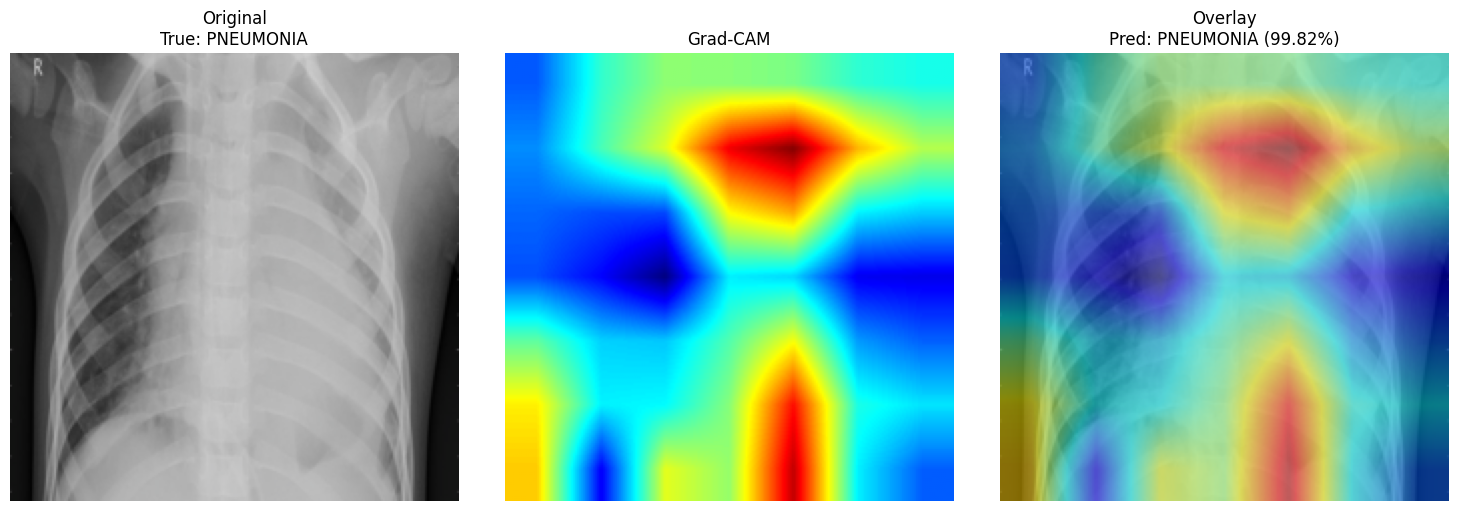

PREDICTION: PNEUMONIA (99.82%)
TRUE LABEL: PNEUMONIA

DIAGNOSTIC REPORT:
Based on the chest X-ray findings, the doctor should look for the following patterns to determine the cause:

* **Bilateral interstitial infiltrates:** Suggests viral pneumonia, characterized by diffuse markings in both lungs.
* **Lobar or segmental consolidation:** Suggests bacterial pneumonia, with an entire lobe or segment appearing white/opaque.

Key features to note on the X-ray:

* Diffuse markings or interstitial infiltrates (viral pneumonia)
* Lobar or segmental consolidation (bacterial pneumonia)
* Presence of air bronchograms (bacterial pneumonia)

Additional clinical information (fever, chills, difficulty breathing) will help the doctor differentiate between viral and bacterial pneumonia, as these symptoms are non-specific and can be present in both.

**Confidence Level:** The doctor should note that a 100% confidence level is not possible with a chest X-ray diagnosis, as there is some overlap between v

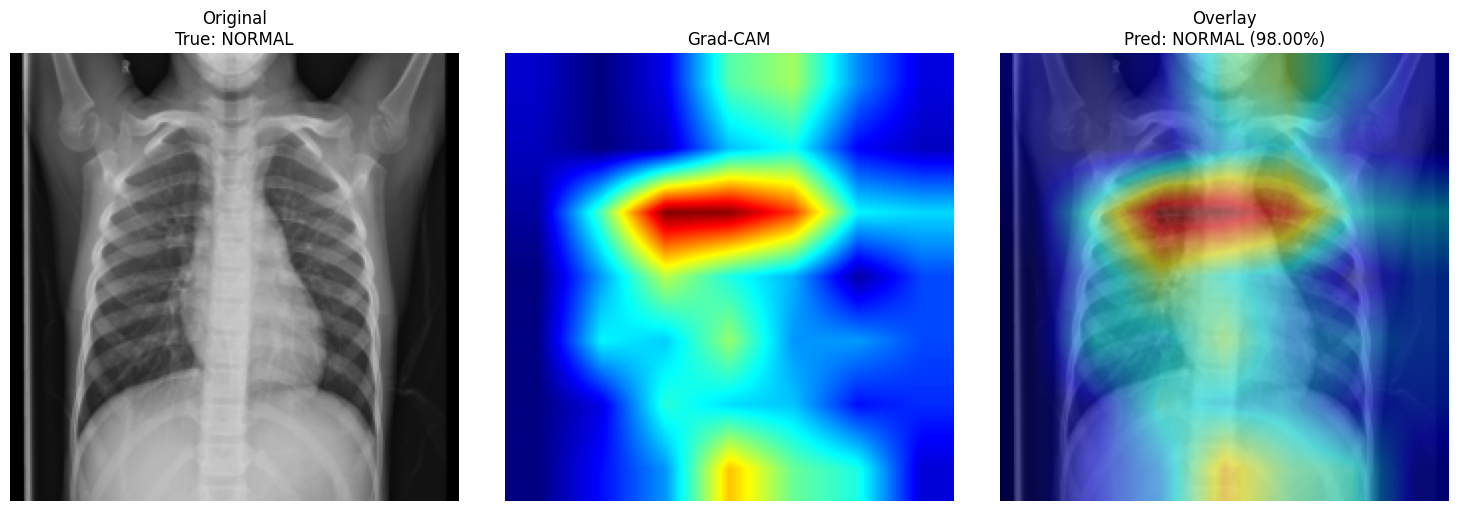

PREDICTION: NORMAL (98.00%)
TRUE LABEL: NORMAL

DIAGNOSTIC REPORT:
Based on the chest X-ray findings, it means that the chest X-ray is essentially normal. This indicates that the lungs appear clear with normal lung markings, no significant white or grey opacities, and no visible air bronchograms.

To confirm normal findings, the doctor should look for:

1. Clear lung fields with a homogeneous dark appearance.
2. Visible lung markings throughout both lungs.
3. A clear costophrenic angle.
4. No white or grey opacities indicative of consolidation.
5. Absence of air bronchograms.

The 98% confidence level indicates a high degree of certainty in the normal chest X-ray findings, suggesting that any potential abnormalities or findings would be minimal and likely not clinically significant.




In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

def generate_gradcam(model, image, target_class):
    model.eval()
    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    handle_f = model.layer4.register_forward_hook(forward_hook)
    handle_b = model.layer4.register_full_backward_hook(backward_hook)

    image = image.to(device)
    output = model(image)
    model.zero_grad()
    output[0][target_class].backward()

    handle_f.remove()
    handle_b.remove()

    grads = gradients[0]
    acts = activations[0]
    weights = grads.mean(dim=[2, 3], keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
    return cam.squeeze().detach().cpu().numpy()

def analyze_xray(image, vectorstore, true_label=None):
    # CNN prediction
    model.eval()
    with torch.no_grad():
        output = model(image.to(device))
        probs = torch.softmax(output, dim=1)[0]
        pred_class = output.argmax(1).item()
        pred_label = ["NORMAL", "PNEUMONIA"][pred_class]
        confidence = probs[pred_class].item()

    # Grad-CAM
    cam = generate_gradcam(model, image, target_class=pred_class)

    # Visualize
    img = image.squeeze().permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.5 * img + 0.5 * heatmap, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title(f'Original\nTrue: {true_label}')
    axes[0].axis('off')
    axes[1].imshow(heatmap)
    axes[1].set_title('Grad-CAM')
    axes[1].axis('off')
    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay\nPred: {pred_label} ({confidence:.2%})')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

    # RAG report
    question = f"The chest xray shows {pred_label} with {confidence:.0%} confidence. \
What does this mean and what should the doctor look for?"
    report, _ = rag_answer(question, vectorstore)

    print(f"{'='*50}")
    print(f"PREDICTION: {pred_label} ({confidence:.2%})")
    print(f"TRUE LABEL: {true_label}")
    print(f"{'='*50}")
    print(f"\nDIAGNOSTIC REPORT:\n{report}")

# Test on 2 images
for i in range(2):
    image, label = next(iter(test_loader))
    true_label = ["NORMAL", "PNEUMONIA"][label.item()]
    analyze_xray(image, vectorstore, true_label)
    print("\n")

In [35]:
from google.colab import files
files.download('week2_rag.ipynb')

FileNotFoundError: Cannot find file: week2_rag.ipynb